<a href="https://colab.research.google.com/github/Amarmurun0212/Diver/blob/main/0610.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Өгөгдлийн эхний 5 мөр:
                Огноо  Үйлдвэрлэсэн эрчим хүч (MWh)  Хэрэглэсэн ус (тонн)  \
0 2023-01-01 00:00:00                        562.35               1171.35   
1 2023-01-01 12:00:00                        533.78               1097.85   
2 2023-01-02 00:00:00                        569.15               1189.89   
3 2023-01-02 12:00:00                        608.54               1310.81   
4 2023-01-03 00:00:00                        529.46               1156.81   

   Мазут хэрэглээ (тонн)  Зуух залгасан тоо  Ажилд залгасан турбины тоо  \
0                   5.27                  6                           6   
1                   3.31                  6                           6   
2                  12.05                  4                           3   
3                   5.25                  5                           3   
4                   4.60                  7                           4   

   Ажилд залгасан зуухны тоо  Аваар саатлын тоо  Дулааны эрчим 

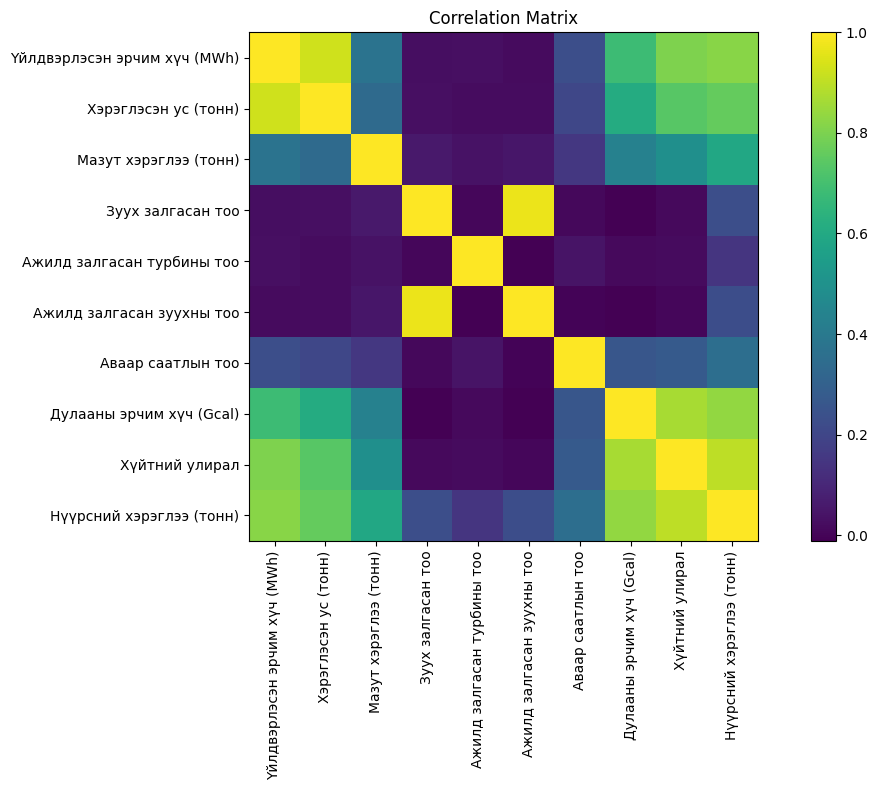


===== ХҮЧТЭЙ КОРРЕЛЯЦ =====
Үйлдвэрлэсэн эрчим хүч (MWh) --> Хүчтэй хамаарал: 0.818
Хэрэглэсэн ус (тонн) --> Хүчтэй хамаарал: 0.759
Мазут хэрэглээ (тонн) --> Дунд хамаарал: 0.594
Зуух залгасан тоо --> Сул хамаарал: 0.230
Ажилд залгасан турбины тоо --> Сул хамаарал: 0.144
Ажилд залгасан зуухны тоо --> Сул хамаарал: 0.226
Аваар саатлын тоо --> Сул хамаарал: 0.355
Дулааны эрчим хүч (Gcal) --> Хүчтэй хамаарал: 0.838
Хүйтний улирал --> Хүчтэй хамаарал: 0.901

Train өгөгдлийн хэмжээ: 960
Test өгөгдлийн хэмжээ: 240

Модел амжилттай сурлаа!

===== МОДЕЛ ҮНЭЛГЭЭ =====
MAE: 47.51
MSE: 3336.74
R2 Score: 0.8713

===== FEATURE IMPORTANCE =====
                        Feature  Importance
8                Хүйтний улирал    0.864252
5     Ажилд залгасан зуухны тоо    0.031035
2         Мазут хэрэглээ (тонн)    0.027352
3             Зуух залгасан тоо    0.021344
7      Дулааны эрчим хүч (Gcal)    0.019266
0  Үйлдвэрлэсэн эрчим хүч (MWh)    0.014810
1          Хэрэглэсэн ус (тонн)    0.012943
4    Ажи

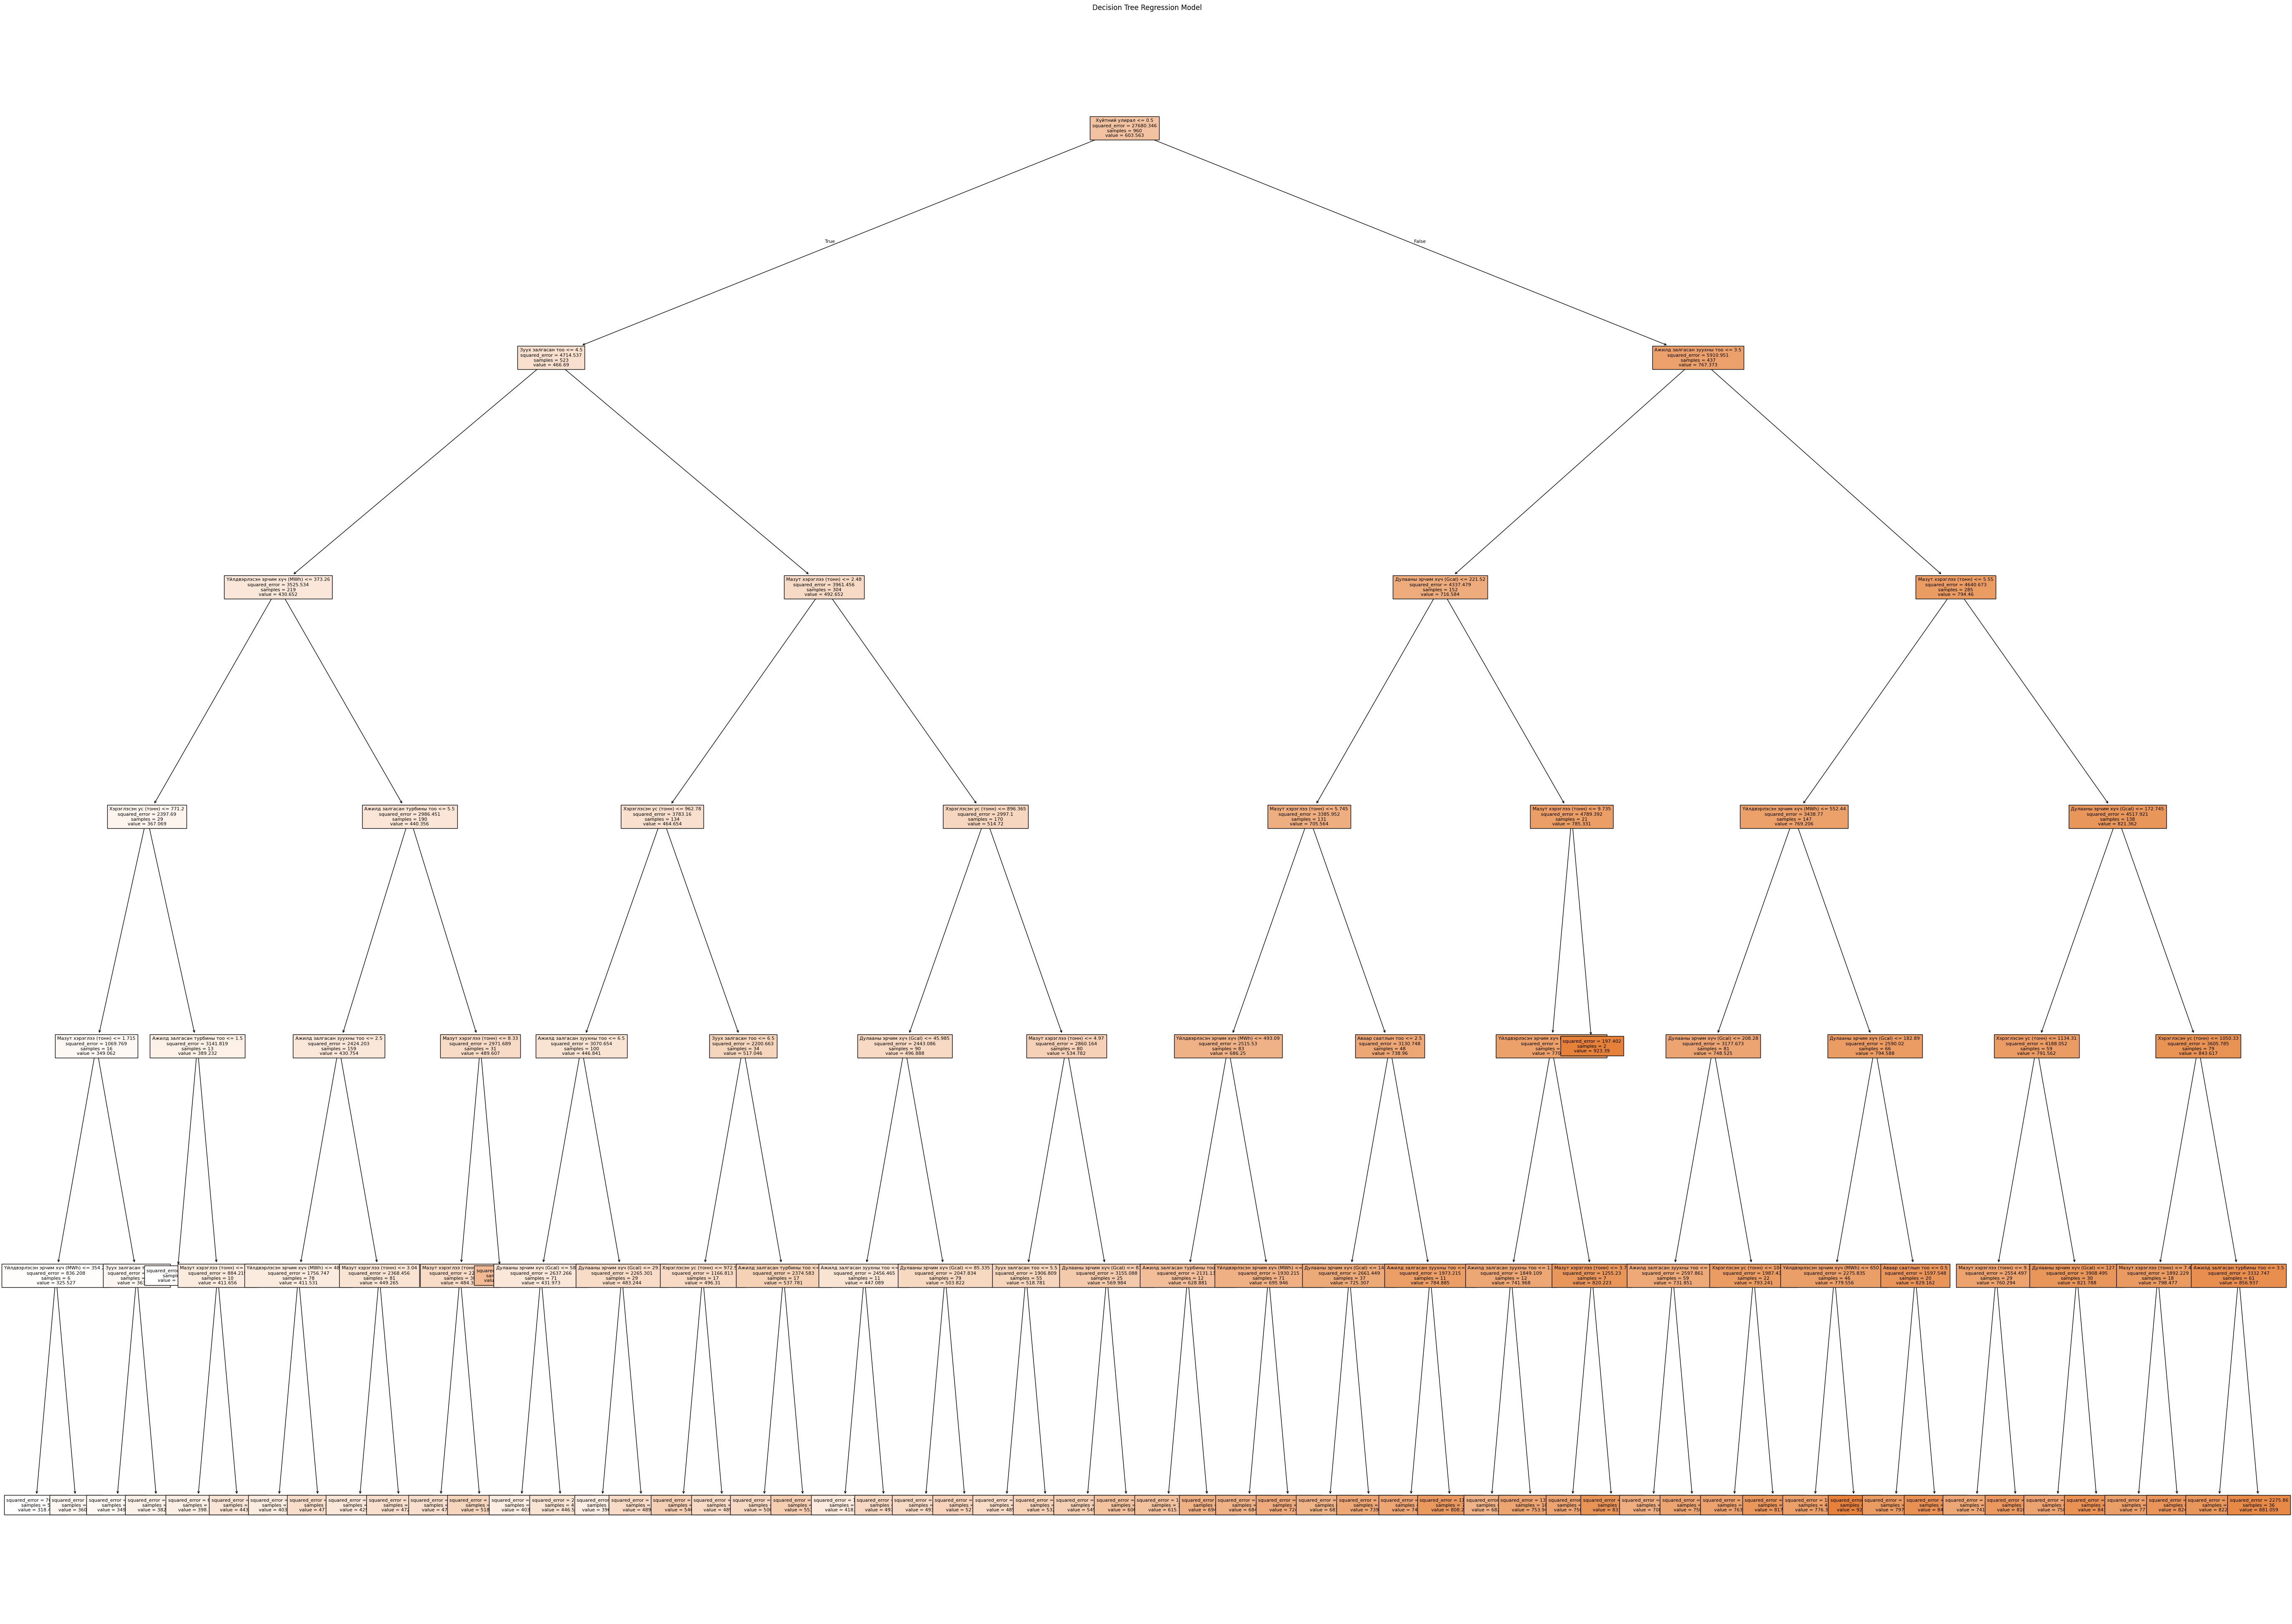


===== ШИНЭ ТААМАГЛАЛ =====
Таамагласан нүүрсний хэрэглээ: 881.06 тонн


In [2]:
# ============================================
# 1. Excel файлаа унших
# ============================================
import pandas as pd
# Excel файл унших
df = pd.read_excel("/content/thermal_power_plant_coal_dataset.xlsx")
# Эхний 5 мөр харах
print("Өгөгдлийн эхний 5 мөр:")
print(df.head())
# ============================================
# Корреляцын коэффициент тооцоолох код
# ============================================
# Сангууд импортлох
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("/content/thermal_power_plant_coal_dataset.xlsx")
# ============================================
# 2. Огноо баганыг хасах
# ============================================
# Корреляц тооцоход datetime хэрэггүй
df_numeric = df.drop(columns=["Огноо"])
# ============================================
# 3. Корреляцын матриц үүсгэх
# ============================================
correlation_matrix = df_numeric.corr()
# ============================================
# 4. Корреляцын хүснэгт хэвлэх
# ============================================
print("===== КОРРЕЛЯЦЫН МАТРИЦ =====")
print(correlation_matrix)
# ============================================
# 5. Нүүрсний хэрэглээтэй холбоо
# ============================================
coal_corr = correlation_matrix[
    "Нүүрсний хэрэглээ (тонн)"
].sort_values(ascending=False)
print("\n===== НҮҮРСНИЙ ХЭРЭГЛЭЭТЭЙ ХАМААРАЛ =====")
print(coal_corr)
# ============================================
# 6. Heatmap зураглах
# ============================================
plt.figure(figsize=(12,8))
#“image show” гэсэн үг. 2 хэмжээст массив/матрицыг өнгөт зураг болгон үзүүлдэг.
plt.imshow(correlation_matrix)
# Тэнхлэгийн нэр
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
# Color bar
plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

# ============================================
# 7. Strong correlation ялгах
# ============================================

print("\n===== ХҮЧТЭЙ КОРРЕЛЯЦ =====")

for col in correlation_matrix.columns:

    corr_value = correlation_matrix.loc[
        col,
        "Нүүрсний хэрэглээ (тонн)"
    ]

    # Өөртэй нь correlation-ийг алгасах
    if col != "Нүүрсний хэрэглээ (тонн)":

        if abs(corr_value) > 0.7:
            print(f"{col} --> Хүчтэй хамаарал: {corr_value:.3f}")

        elif abs(corr_value) > 0.4:
            print(f"{col} --> Дунд хамаарал: {corr_value:.3f}")

        else:
            print(f"{col} --> Сул хамаарал: {corr_value:.3f}")

# ============================================
# Decision Tree Regression ашиглан
# Нүүрсний хэрэглээ таамаглах машин сургалт
# ============================================
# Ашиглах сангуудыг импортлох
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn import tree
# ============================================
# 2. Feature болон target салгах
# ============================================
# X = Оролтын өгөгдөл
X = df[
    [   "Үйлдвэрлэсэн эрчим хүч (MWh)","Хэрэглэсэн ус (тонн)","Мазут хэрэглээ (тонн)","Зуух залгасан тоо","Ажилд залгасан турбины тоо","Ажилд залгасан зуухны тоо",
        "Аваар саатлын тоо",
        "Дулааны эрчим хүч (Gcal)",
        "Хүйтний улирал"
    ]
]
# y = Таамаглах утга
y = df["Нүүрсний хэрэглээ (тонн)"]
# ============================================
# 3. Train/Test өгөгдөл болгон хуваах
# ============================================
# 80% train
# 20% test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42
)

print("\nTrain өгөгдлийн хэмжээ:", len(X_train))
print("Test өгөгдлийн хэмжээ:", len(X_test))

# ============================================
# 4. Decision Tree Regressor модел үүсгэх
# ============================================

model = DecisionTreeRegressor(
    max_depth=6,          # Модны хамгийн их гүн
    min_samples_split=5,  # Split хийх minimum sample
    random_state=42
)

# ============================================
# 5. Модел сургах
# ============================================

model.fit(X_train, y_train)

print("\nМодел амжилттай сурлаа!")

# ============================================
# 6. Таамаглал хийх
# ============================================

y_pred = model.predict(X_test)

# ============================================
# 7. Моделын үнэлгээ
# ============================================

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("\n===== МОДЕЛ ҮНЭЛГЭЭ =====")

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

# ============================================
# 8. Feature importance харах
# ============================================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Importance-оор эрэмбэлэх
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====")
print(importance_df)

# ============================================
# 9. Decision Tree дүрслэх
# ============================================

plt.figure(figsize=(70
      ,50))

tree.plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Regression Model")
plt.show()

# ============================================
# 10. Шинэ өгөгдөл дээр prediction хийх
# ============================================

new_data = pd.DataFrame({
    "Үйлдвэрлэсэн эрчим хүч (MWh)": [620],
    "Хэрэглэсэн ус (тонн)": [1300],
    "Мазут хэрэглээ (тонн)": [6],
    "Зуух залгасан тоо": [6],
    "Ажилд залгасан турбины тоо": [5],
    "Ажилд залгасан зуухны тоо": [5],
    "Аваар саатлын тоо": [0],
    "Дулааны эрчим хүч (Gcal)": [190],
    "Хүйтний улирал": [1]
})

prediction = model.predict(new_data)

print("\n===== ШИНЭ ТААМАГЛАЛ =====")
print(f"Таамагласан нүүрсний хэрэглээ: {prediction[0]:.2f} тонн")

